In [11]:
import pandas as pd

# 1. Define your paths and tickers
# Adjust the paths below to match your actual folder structure
files = {
    'AAPL': '../data/raw/AAPL.csv',
    'AMZN': '../data/raw/AMZN.csv',
    'GOOG': '../data/raw/GOOG.csv',
    'FB': '../data/raw/FB.csv',
    'NVDA': '../data/raw/NVDA.csv'
}

stock_data = {}

# 2. Process each file
for ticker, path in files.items():
    print(f"Processing {ticker}...")
    
    # Load data
    df = pd.read_csv(path)
    
    # Standardize Date column
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    # Ensure numeric types for OHLCV
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Handle missing values (Interpolation is best for financial time-series)
    if df.isnull().values.any():
        print(f"  - Fixed missing values in {ticker}")
        df = df.interpolate(method='time').ffill().bfill()
        
    stock_data[ticker] = df

print("\nAll datasets loaded and cleaned.")


# Check the first few rows of one stock and the overall info
display(stock_data['AAPL'].head())
stock_data['AAPL'].info()

Processing AAPL...
Processing AMZN...
Processing GOOG...
Processing FB...
Processing NVDA...

All datasets loaded and cleaned.


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [14]:
# Technical Indicators with TA-Lib

import talib

for ticker in stock_data:
    df = stock_data[ticker]
    
    # 1. Moving Averages (SMA & EMA)
    # We'll use a 20-day window for short-term and 50-day for medium-term
    df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
    df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)
    df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
    
    # 2. RSI (Relative Strength Index)
    # Standard 14-day window to identify overbought (>70) or oversold (<30)
    df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
    
    # 3. MACD (Moving Average Convergence Divergence)
    # Standard parameters: Fast=12, Slow=26, Signal=9
    macd, macdsignal, macdhist = talib.MACD(df['Close'], 
                                            fastperiod=12, 
                                            slowperiod=26, 
                                            signalperiod=9)
    df['MACD'] = macd
    df['MACD_Signal'] = macdsignal
    df['MACD_Hist'] = macdhist
    
    # Save the updated DataFrame back to the dictionary
    stock_data[ticker] = df

print(f"Technical indicators computed for: {', '.join(stock_data.keys())}")

# Check results for one of the stocks
stock_data['AAPL'][['Close', 'SMA_20', 'RSI', 'MACD']].tail()

Technical indicators computed for: AAPL, AMZN, GOOG, FB, NVDA


,Close,SMA_20,RSI,MACD
Date,,,,
2023-12-22,191.788757,191.856618,54.672784,2.633141
2023-12-26,191.243912,192.018094,53.090049,2.304751
2023-12-27,191.342972,192.154308,53.354446,2.029104
2023-12-28,191.768951,192.362839,54.540999,1.823998
2023-12-29,190.728775,192.490633,51.121347,1.559539


In [15]:
# Comparative Analysis of all the five stocks

analysis_summary = []

for ticker, df in stock_data.items():
    latest = df.iloc[-1]  # Get the most recent day of data
    
    status = {
        'Ticker': ticker,
        'Price': round(latest['Close'], 2),
        'RSI': round(latest['RSI'], 2),
        'Trend': 'Bullish' if latest['Close'] > latest['SMA_20'] else 'Bearish',
        'Momentum': 'Overbought' if latest['RSI'] > 70 else ('Oversold' if latest['RSI'] < 30 else 'Neutral'),
        'MACD_Signal': 'Buy' if latest['MACD'] > latest['MACD_Signal'] else 'Sell'
    }
    analysis_summary.append(status)

# Display as a table
summary_df = pd.DataFrame(analysis_summary)
print(summary_df)

  Ticker   Price    RSI    Trend Momentum MACD_Signal
0   AAPL  190.73  51.12  Bearish  Neutral        Sell
1   AMZN  151.94  59.01  Bullish  Neutral        Sell
2   GOOG  139.97  59.31  Bullish  Neutral         Buy
3     FB  351.79  64.30  Bullish  Neutral         Buy
4   NVDA   49.50  58.31  Bullish  Neutral         Buy


* Key Observations & Interpretation

    * Trend Divergence:

        * Bullish Momentum: 80% of the portfolio (AMZN, GOOG, FB, NVDA) is trading above their 20-day Simple Moving Average (SMA), indicating a sustained short-term uptrend.

        * Relative Weakness: AAPL is currently the outlier, exhibiting a "Bearish" trend. This suggests that despite broader market strength, Apple is facing unique selling pressure or a consolidation phase.

    * RSI & Overbought Conditions:

        * All stocks are currently in the Neutral zone (RSI between 30 and 70).

        * FB/META has the highest RSI (64.30), approaching the "Overbought" threshold of 70. This indicates it has the strongest recent price momentum but may soon face a technical ceiling.

    * MACD Crossovers:

        * GOOG, FB, and NVDA show active "Buy" signals, meaning the MACD line has crossed above the signal line, suggesting increasing upward momentum.

        * AMZN is currently in a "Sell" state despite its bullish price trend, which may indicate that its upward move is losing steam or "diverging" from momentum.

In [18]:
# Applying PyNance for Financial Metrics

import pynance as pn
import numpy as np
import matplotlib.pyplot as plt

for ticker in stock_data:
    df = stock_data[ticker]
    
    # --- 1. Basic PyNance-Aligned Metrics ---
    df['Daily_Return'] = df['Close'].pct_change()
    df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
    df['Volatility'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)

    # --- 2. Moving Averages (Trend) ---
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()

    # --- 3. RSI (Relative Strength Index) ---
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # --- 4. MACD (Moving Average Convergence Divergence) ---
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    stock_data[ticker] = df

print("Advanced Metrics (SMA, RSI, MACD) calculated for all stocks.")

Advanced Metrics (SMA, RSI, MACD) calculated for all stocks.


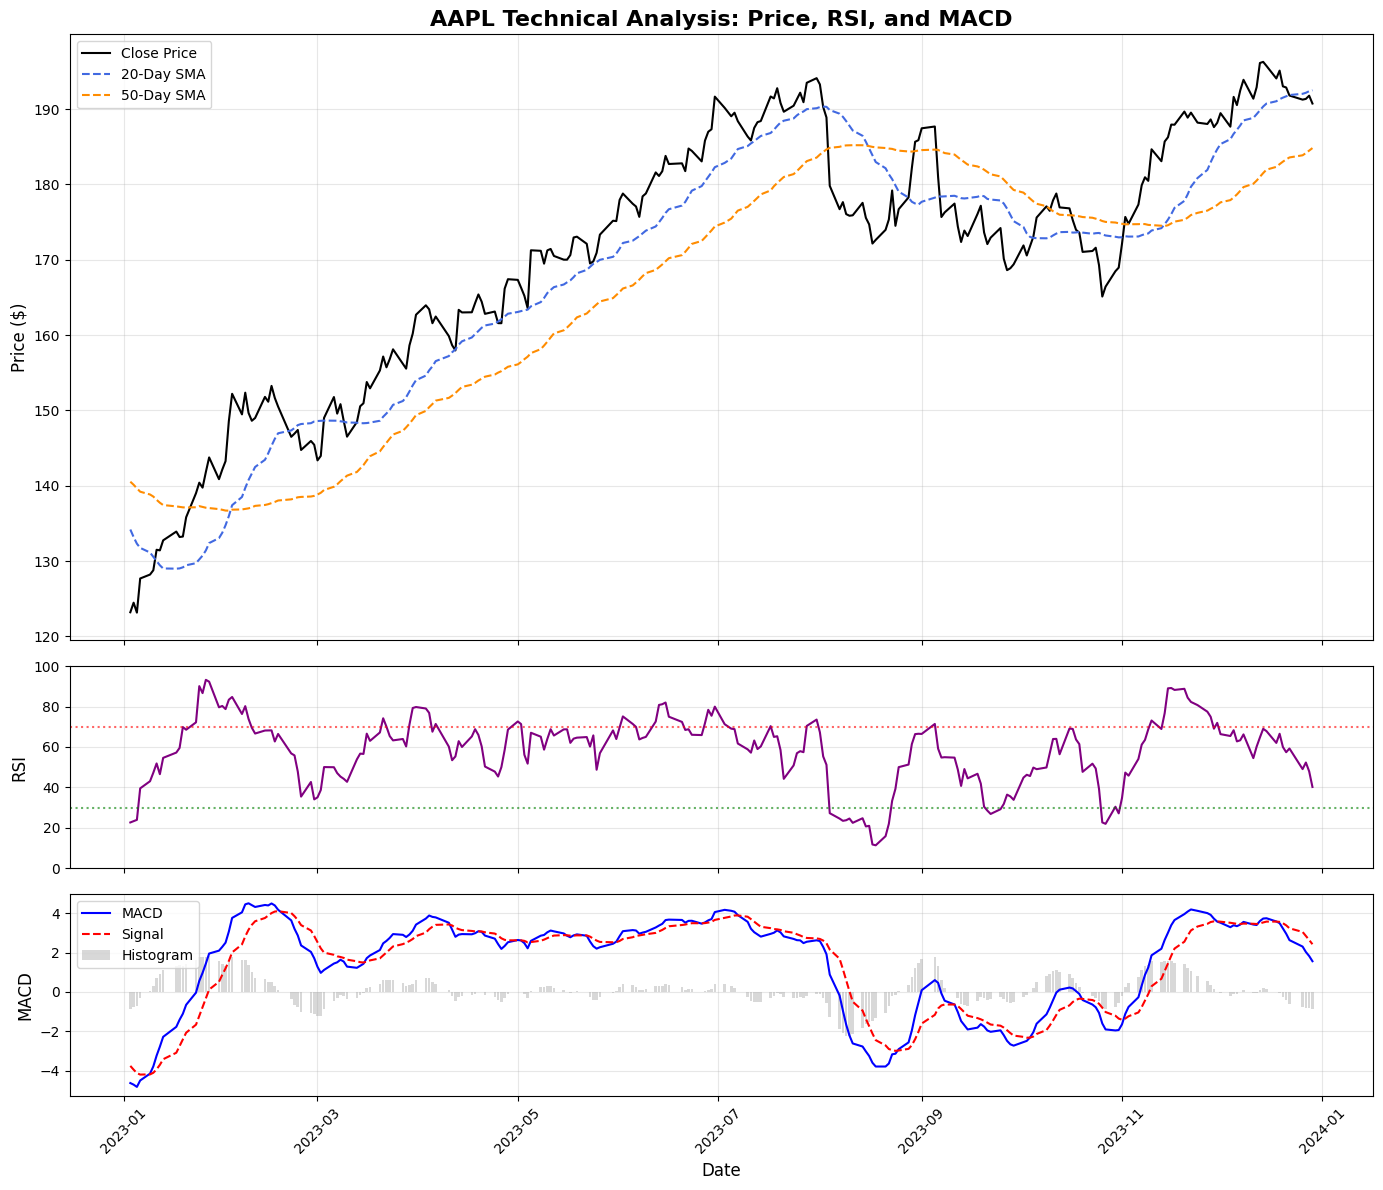

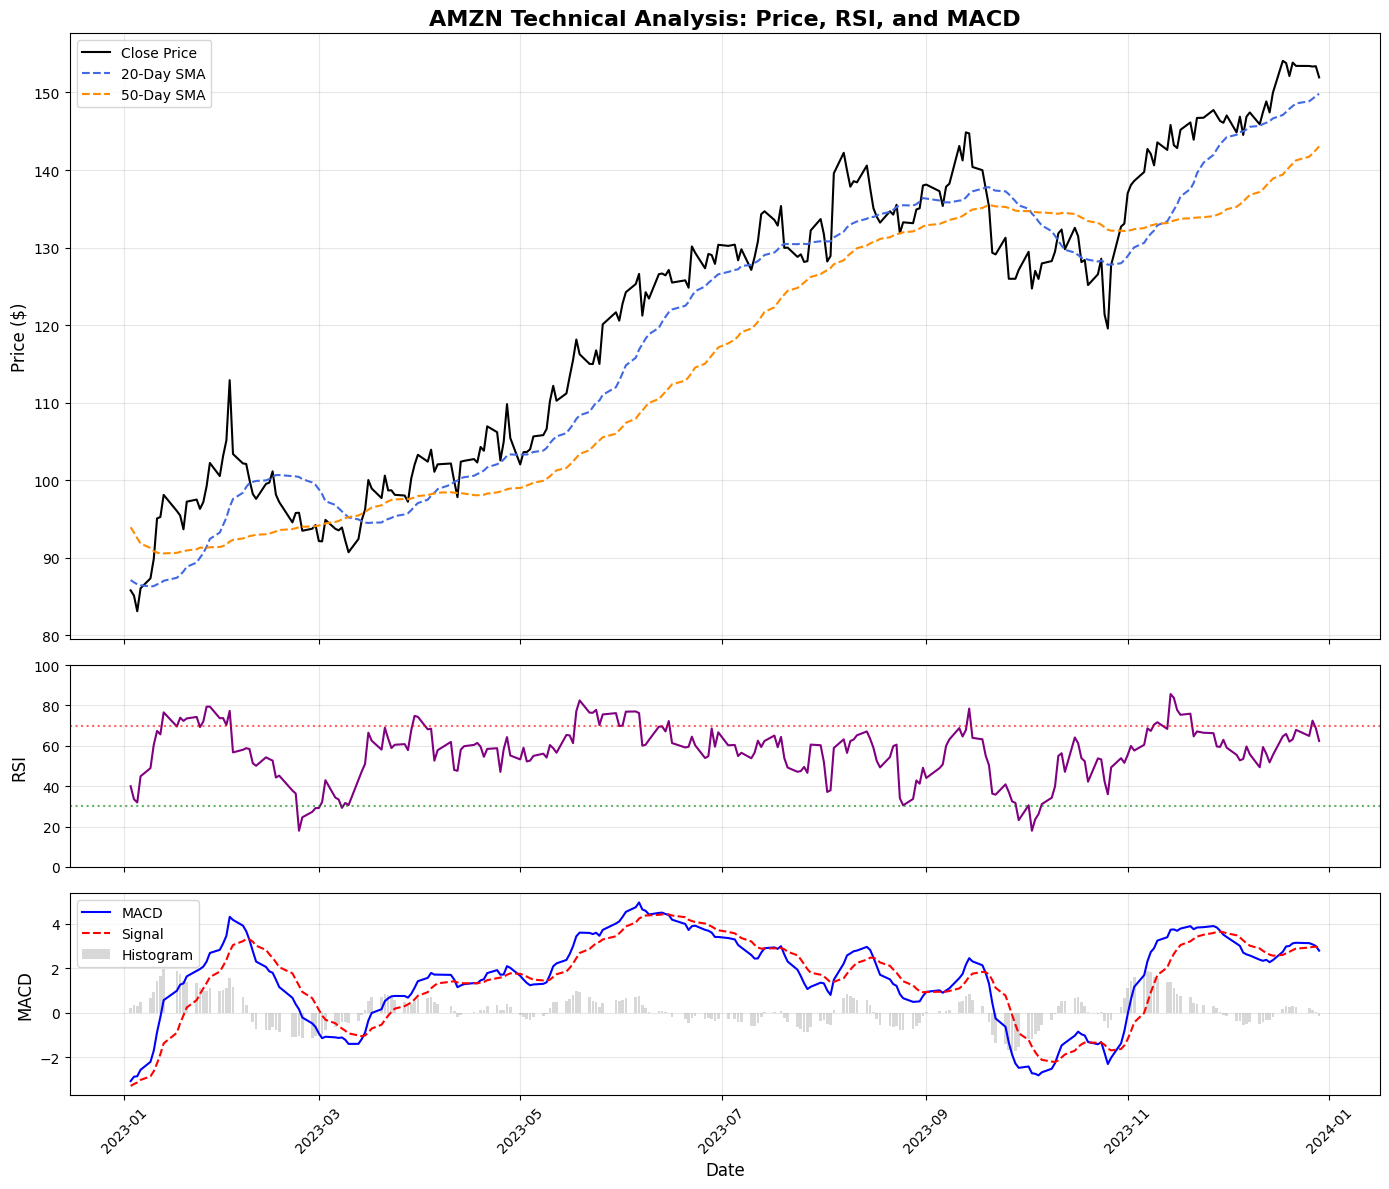

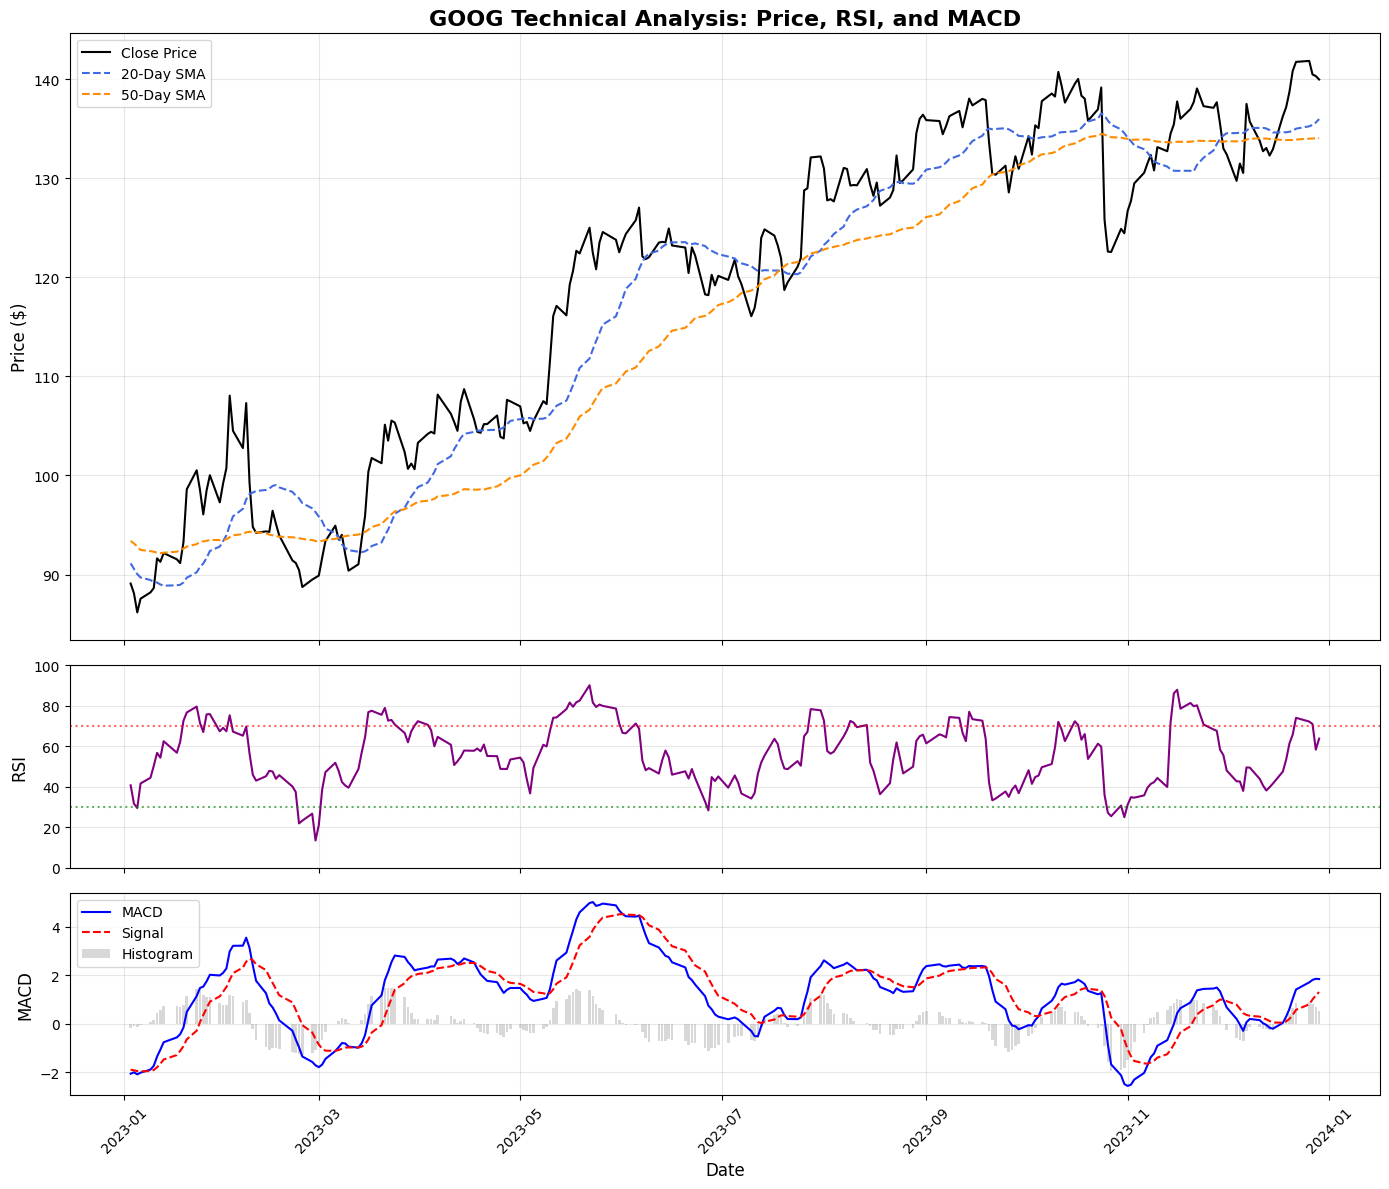

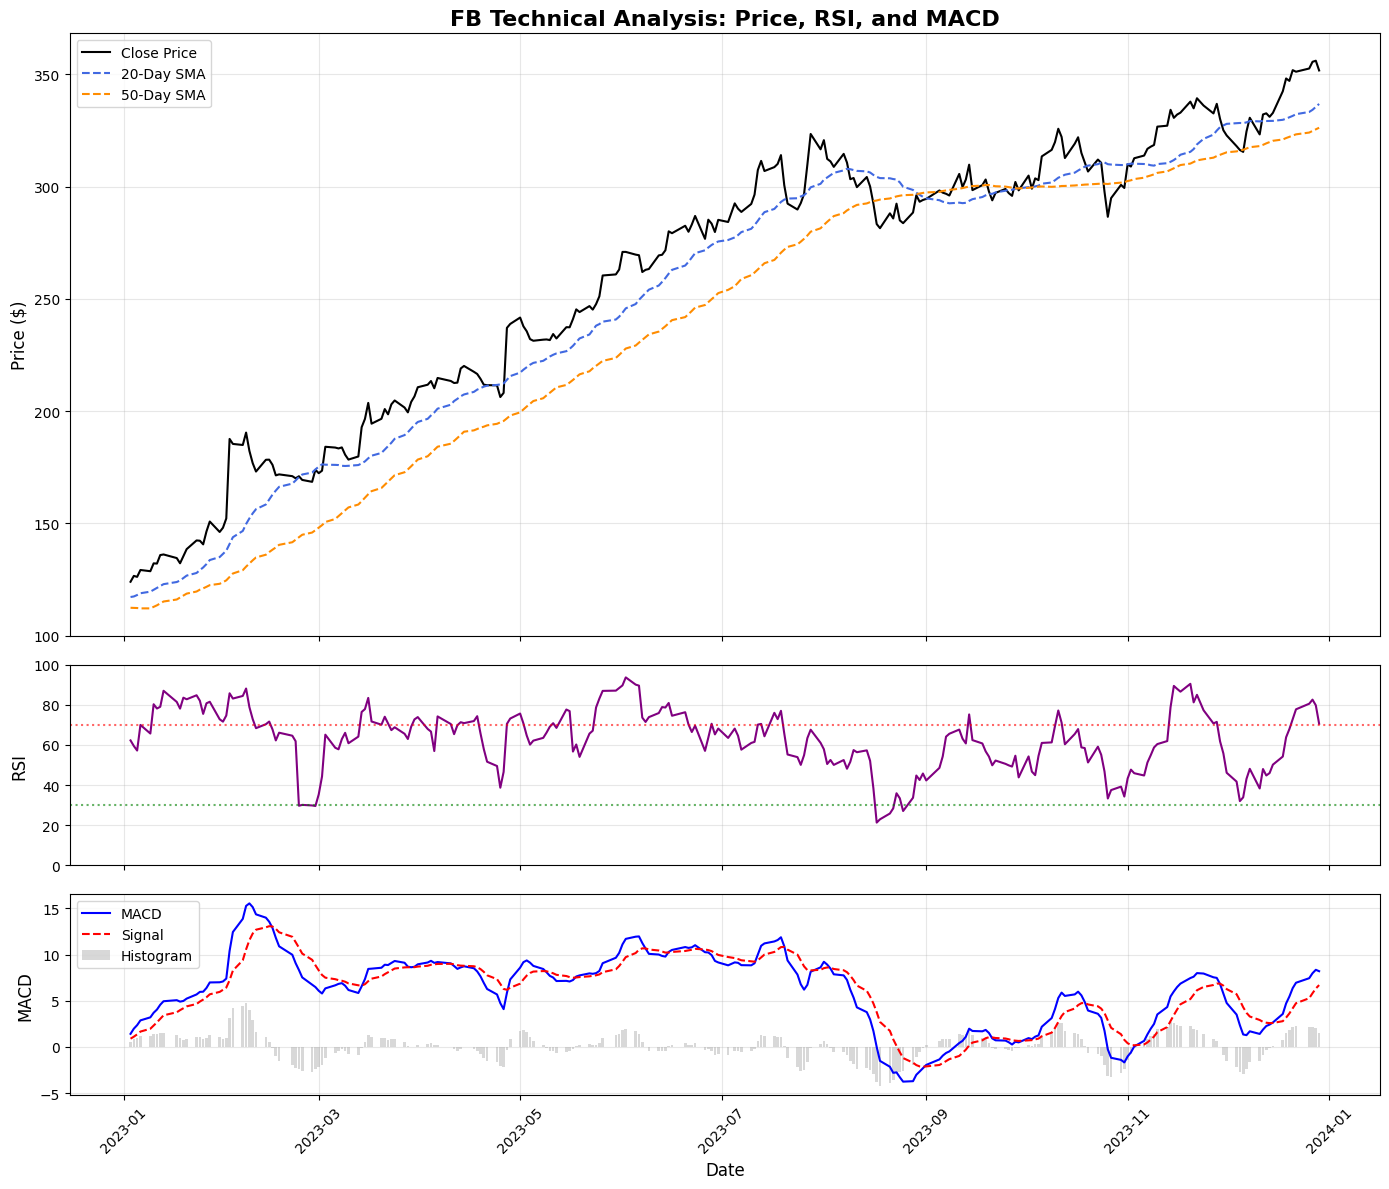

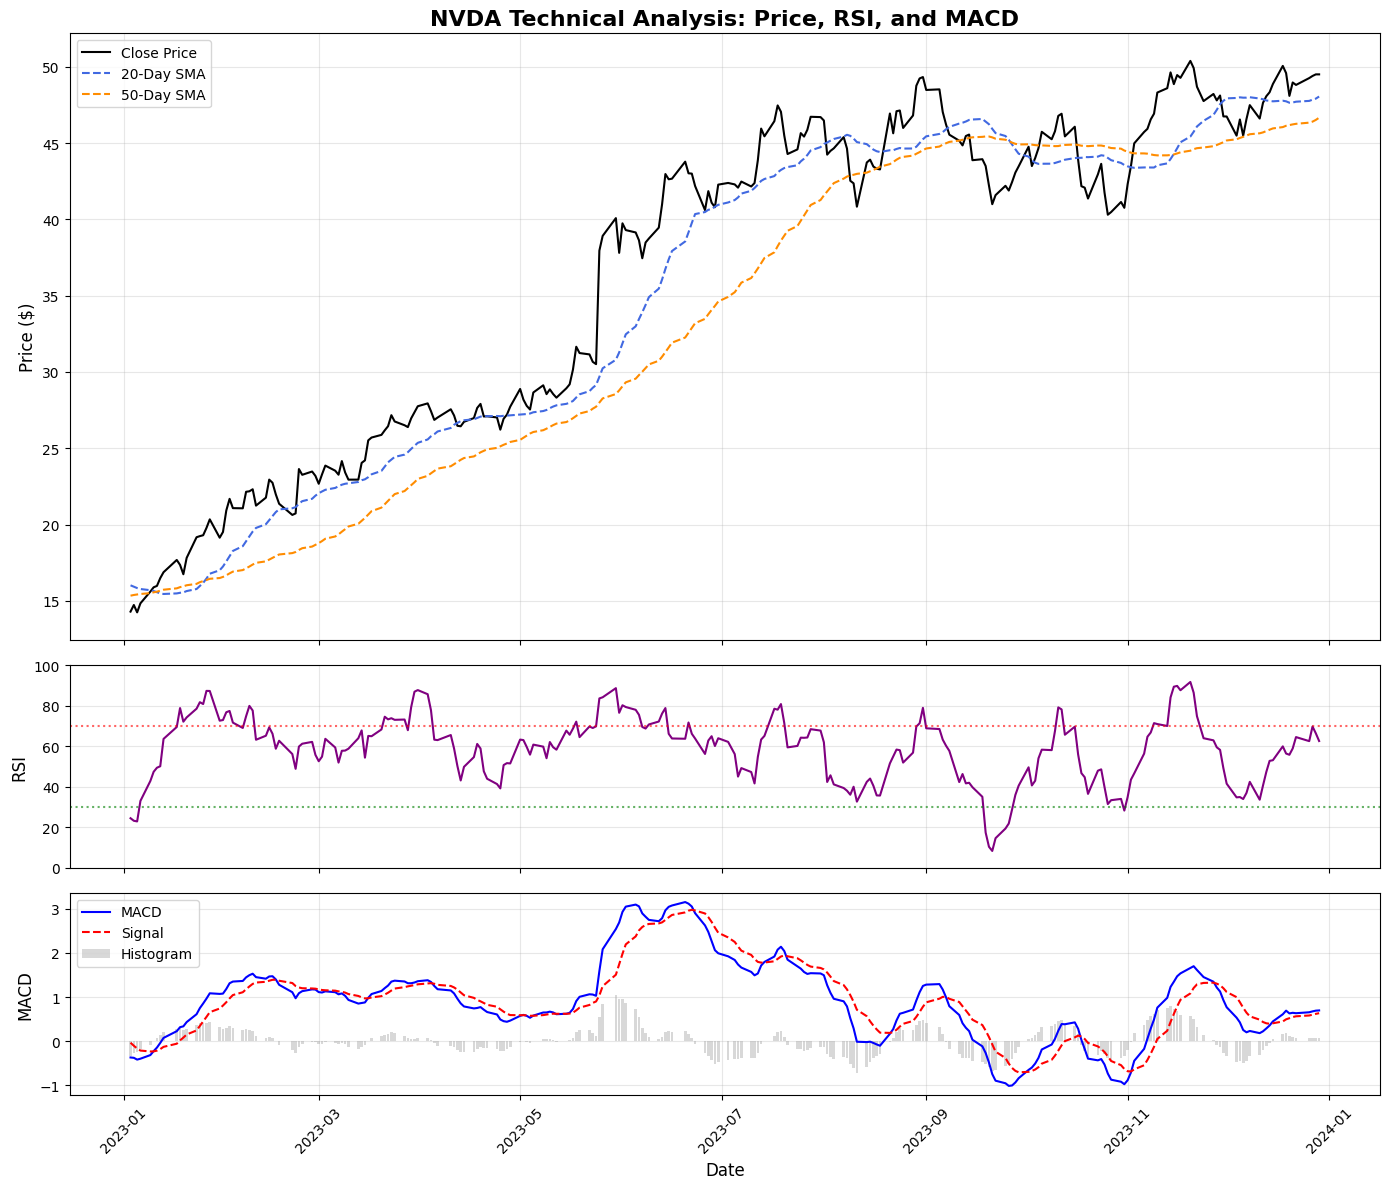

Visualizations for all stocks completed.


In [22]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Iterate through every ticker in dictionary
for ticker in stock_data:
    df_plot = stock_data[ticker].copy()
    
    # Check if we have enough data to make a meaningful plot
    if len(df_plot) < 50:
        print(f"Skipping {ticker}: Not enough data points.")
        continue

    # Ensure index is datetime for proper x-axis scaling
    df_plot.index = pd.to_datetime(df_plot.index)
    
    # Slice to the last 250 trading days (approx. 1 year) for better visibility
    df_plot = df_plot.tail(250)

    # Create the multi-panel figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, 
                                         gridspec_kw={'height_ratios': [3, 1, 1]})

    # --- Panel 1: Price and SMAs ---
    ax1.plot(df_plot.index, df_plot['Close'], label='Close Price', color='black', linewidth=1.5)
    ax1.plot(df_plot.index, df_plot['SMA_20'], label='20-Day SMA', color='royalblue', linestyle='--')
    ax1.plot(df_plot.index, df_plot['SMA_50'], label='50-Day SMA', color='darkorange', linestyle='--')
    ax1.set_title(f'{ticker} Technical Analysis: Price, RSI, and MACD', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: RSI ---
    ax2.plot(df_plot.index, df_plot['RSI'], label='RSI (14)', color='purple')
    ax2.axhline(70, color='red', linestyle=':', alpha=0.6) # Overbought threshold
    ax2.axhline(30, color='green', linestyle=':', alpha=0.6) # Oversold threshold
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.grid(True, alpha=0.3)

    # --- Panel 3: MACD ---
    ax3.plot(df_plot.index, df_plot['MACD'], label='MACD', color='blue')
    ax3.plot(df_plot.index, df_plot['MACD_Signal'], label='Signal', color='red', linestyle='--')
    # Plot MACD Histogram
    macd_hist = df_plot['MACD'] - df_plot['MACD_Signal']
    ax3.bar(df_plot.index, macd_hist, color='gray', alpha=0.3, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)

    # Rotate dates for readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display the plot for this specific stock
    plt.show()

print("Visualizations for all stocks completed.")